In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nirmeetp/chicago-crime-dataset/Crimes_-_2001_to_Present.csv


In [2]:
!pip install "dask[distributed]"

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import sqrt
import matplotlib.ticker as mticker

import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

# plt.style.use('seaborn-v0_8')
# plotColors = (list(mcolors.TABLEAU_COLORS)*3)[:23]

In [4]:
cluster = LocalCluster()
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:45361' processes=4 threads=4, memory=30.00 GiB>


In [5]:
import os

# 1. Define the Kaggle path
# Replace 'chicago-crime' with whatever you named your dataset when you uploaded it
DATA_PATH = '/kaggle/input/datasets/nirmeetp/chicago-crime-dataset/Crimes_-_2001_to_Present.csv' 

# 2. Verify the file exists (This helps debug path errors)
if os.path.exists(DATA_PATH):
    print(f"File found at: {DATA_PATH}")
else:
    # This prints all available files so you can find the correct path if the above fails
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            print(os.path.join(dirname, filename))

File found at: /kaggle/input/datasets/nirmeetp/chicago-crime-dataset/Crimes_-_2001_to_Present.csv


In [6]:

allCrimes = dd.read_csv(
    DATA_PATH,
    dtype={
        'X Coordinate': 'float64',
        'Y Coordinate': 'float64',
        'Ward': 'float64',
        'Community Area': 'float64',
        'District': 'float64',
        'FBI Code':'object',
        'IUCR':'object',
        'ID':'object'
    },
    assume_missing=True
)

print(allCrimes.dtypes)
print("Partitions:", allCrimes.npartitions)

ID                      string[pyarrow]
Case Number             string[pyarrow]
Date                    string[pyarrow]
Block                   string[pyarrow]
IUCR                    string[pyarrow]
Primary Type            string[pyarrow]
Description             string[pyarrow]
Location Description    string[pyarrow]
Arrest                             bool
Domestic                           bool
Beat                            float64
District                        float64
Ward                            float64
Community Area                  float64
FBI Code                string[pyarrow]
X Coordinate                    float64
Y Coordinate                    float64
Year                            float64
Updated On              string[pyarrow]
Latitude                        float64
Longitude                       float64
Location                string[pyarrow]
dtype: object
Partitions: 31


In [7]:
# Removing duplicates
allCrimes = allCrimes.map_partitions(lambda df: df.drop_duplicates(subset="ID"))
print("Dedup done — no cross-partition shuffle needed")

Dedup done — no cross-partition shuffle needed


In [8]:
# Removing NaN values
#(removing entire row if a NaN value is present)
allCrimes = allCrimes.dropna()
print("Records after dropping NaN:", len(allCrimes))

Records after dropping NaN: 7818867


In [9]:
# Removing invalid coordinates
#(remove where coordinates are 0, they are clearly wring/missing)


allCrimes = allCrimes[
    (allCrimes['X Coordinate'] != 0) &
    (allCrimes['Y Coordinate'] != 0) &
    (allCrimes['Longitude'] != 0) &
    (allCrimes['Latitude'] != 0)
]
print("Records after removing bad locations:", len(allCrimes))

Records after removing bad locations: 7818757


In [10]:
# convert date column from string to object
allCrimes['Date'] = dd.to_datetime(allCrimes['Date'], format='%m/%d/%Y %I:%M:%S %p')

In [11]:
# extracting time features from date
allCrimes['Hour']      = allCrimes['Date'].dt.hour
allCrimes['Month']     = allCrimes['Date'].dt.month
allCrimes['DayOfWeek'] = allCrimes['Date'].dt.dayofweek
allCrimes['Year']      = allCrimes['Date'].dt.year

In [12]:
# keep top 25 crime locations
# Compute value counts (this triggers execution)
loc_counts = allCrimes['Location Description'].value_counts().compute()
mostFrequentLocations = list(loc_counts[:25].index)

# Replace rare locations with 'OTHER'
allCrimes['Location Description'] = allCrimes['Location Description'].where(
    allCrimes['Location Description'].isin(mostFrequentLocations),
    other='OTHER'
)

# Same for Description column
desc_counts = allCrimes['Description'].value_counts().compute()
mostFrequentDescription = list(desc_counts[:25].index)

allCrimes['Description'] = allCrimes['Description'].where(
    allCrimes['Description'].isin(mostFrequentDescription),
    other='OTHER'
)

2026-04-18 06:56:39,293 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 492d4b2fd357e66de5b919065ce40657 initialized by task ('shuffle-transfer-492d4b2fd357e66de5b919065ce40657', 19) executed on worker tcp://127.0.0.1:36179
2026-04-18 06:57:01,936 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 492d4b2fd357e66de5b919065ce40657 deactivated due to stimulus 'task-finished-1776495421.9351497'
2026-04-18 06:57:09,067 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0984dd98b3190792f718599bcd2d8678 initialized by task ('shuffle-transfer-0984dd98b3190792f718599bcd2d8678', 2) executed on worker tcp://127.0.0.1:36179
2026-04-18 06:57:33,557 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0984dd98b3190792f718599bcd2d8678 deactivated due to stimulus 'task-finished-1776495453.556396'


In [15]:
# convert to categorical for increasing speed
allCrimes['Primary Type']         = allCrimes['Primary Type'].astype('category')
allCrimes['Location Description'] = allCrimes['Location Description'].astype('category')
allCrimes['Description']          = allCrimes['Description'].astype('category')

In [16]:
# drop unnecessary columns
allCrimes = allCrimes.drop(
    columns=['Case Number', 'IUCR', 'Updated On', 'FBI Code', 'Beat', 'Ward'],
    errors='ignore'
)

In [17]:
# THIS is where all the above lazy steps actually execute (this is lazy evaluation of Dask)
allCrimes = allCrimes.compute()

print("Final clean dataset shape:", allCrimes.shape)
allCrimes.head()

Final clean dataset shape: (7818757, 19)


,ID,Date,Block,Primary Type,Description,Location Description,Arrest,Domestic,District,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Location,Hour,Month,DayOfWeek
2,12131221,2020-08-10 09:45:00,015XX N DAMEN AVE,ROBBERY,OTHER,OTHER,True,False,14.0,24.0,1162795.0,1909900.0,2020,41.908418,-87.677407,"(41.908417822, -87.67740693)",9,8,0
4,13203321,2023-09-06 17:00:00,002XX N Wells st,CRIMINAL DAMAGE,OTHER,OTHER,False,False,1.0,32.0,1174694.0,1901831.0,2023,41.886018,-87.633938,"(41.886018055, -87.633937881)",17,9,2
5,13204489,2023-09-06 11:00:00,0000X E 8TH ST,THEFT,OTHER,OTHER,False,False,1.0,32.0,1176857.0,1896680.0,2023,41.871835,-87.626151,"(41.871834768, -87.62615082)",11,9,2
6,11695116,2019-05-21 08:20:00,018XX S CALIFORNIA AVE,BURGLARY,OTHER,OTHER,False,False,10.0,29.0,1157982.0,1890961.0,2019,41.856547,-87.695605,"(41.856547057, -87.695604526)",8,5,1
7,12419690,2021-07-07 10:30:00,132XX S GREENWOOD AVE,SEX OFFENSE,OTHER,OTHER,False,False,5.0,54.0,1186051.0,1817781.0,2021,41.655116,-87.594883,"(41.65511579, -87.594883198)",10,7,2


In [18]:
4# creating a backup
backup = allCrimes.copy()

In [19]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

In [20]:
DAY_NAMES   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [21]:
print("\n--- Dataset shape ---")
print(f"Rows: {allCrimes.shape[0]:,}   Columns: {allCrimes.shape[1]}")


--- Dataset shape ---
Rows: 7,818,757   Columns: 19


In [22]:
print("\n--- Column names & types ---")
print(allCrimes.dtypes)


--- Column names & types ---
ID                      string[pyarrow]
Date                     datetime64[ns]
Block                   string[pyarrow]
Primary Type                   category
Description                    category
Location Description           category
Arrest                             bool
Domestic                           bool
District                        float64
Community Area                  float64
X Coordinate                    float64
Y Coordinate                    float64
Year                              int32
Latitude                        float64
Longitude                       float64
Location                string[pyarrow]
Hour                              int32
Month                             int32
DayOfWeek                         int32
dtype: object


In [23]:
print("\n--- Numeric columns summary ---")
print(allCrimes[['Year', 'Hour', 'Month', 'DayOfWeek',
                  'District', 'Community Area']].describe().round(2))



--- Numeric columns summary ---
             Year        Hour       Month   DayOfWeek    District  \
count  7818757.00  7818757.00  7818757.00  7818757.00  7818757.00   
mean      2011.94       13.07        6.61        3.00       11.28   
std          6.90        6.76        3.33        1.99        6.96   
min       2001.00        0.00        1.00        0.00        1.00   
25%       2006.00        9.00        4.00        1.00        6.00   
50%       2011.00       14.00        7.00        3.00       10.00   
75%       2018.00       19.00        9.00        5.00       17.00   
max       2026.00       23.00       12.00        6.00       31.00   

       Community Area  
count      7818757.00  
mean            37.38  
std             21.53  
min              0.00  
25%             23.00  
50%             32.00  
75%             56.00  
max             77.00  


In [24]:
print("\n--- Primary Type (top 10 most frequent) ---")
print(allCrimes['Primary Type'].value_counts().head(10))


--- Primary Type (top 10 most frequent) ---
Primary Type
THEFT                  1668867
BATTERY                1430103
CRIMINAL DAMAGE         894172
NARCOTICS               687865
ASSAULT                 531835
OTHER OFFENSE           488998
BURGLARY                416809
MOTOR VEHICLE THEFT     403187
DECEPTIVE PRACTICE      345919
ROBBERY                 292288
Name: count, dtype: int64


In [25]:
print("\n--- Location Description (top 10) ---")
print(allCrimes['Location Description'].value_counts().head(10))


--- Location Description (top 10) ---
Location Description
OTHER                             7455461
PARKING LOT/GARAGE(NON.RESID.)     181667
DRUG STORE                          36873
CHA APARTMENT                       33087
BANK                                30203
CTA BUS                             26261
RESIDENCE - PORCH / HALLWAY         18940
BARBERSHOP                           8260
MEDICAL/DENTAL OFFICE                6619
FACTORY/MANUFACTURING BUILDING       5957
Name: count, dtype: int64


In [26]:
print("\n--- Arrest rate ---")
print(f"{allCrimes['Arrest'].mean() * 100:.1f}% of crimes led to an arrest")


--- Arrest rate ---
24.8% of crimes led to an arrest


In [27]:
print("\n--- Domestic crime rate ---")
print(f"{allCrimes['Domestic'].mean() * 100:.1f}% of crimes were domestic")


--- Domestic crime rate ---
17.4% of crimes were domestic


In [28]:
print("\n--- Year range ---")
print(f"Data spans: {int(allCrimes['Year'].min())} to {int(allCrimes['Year'].max())}")


--- Year range ---
Data spans: 2001 to 2026


In [29]:
print("\n--- Missing values after cleaning ---")
print(allCrimes.isnull().sum())


--- Missing values after cleaning ---
ID                      0
Date                    0
Block                   0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
District                0
Community Area          0
X Coordinate            0
Y Coordinate            0
Year                    0
Latitude                0
Longitude               0
Location                0
Hour                    0
Month                   0
DayOfWeek               0
dtype: int64


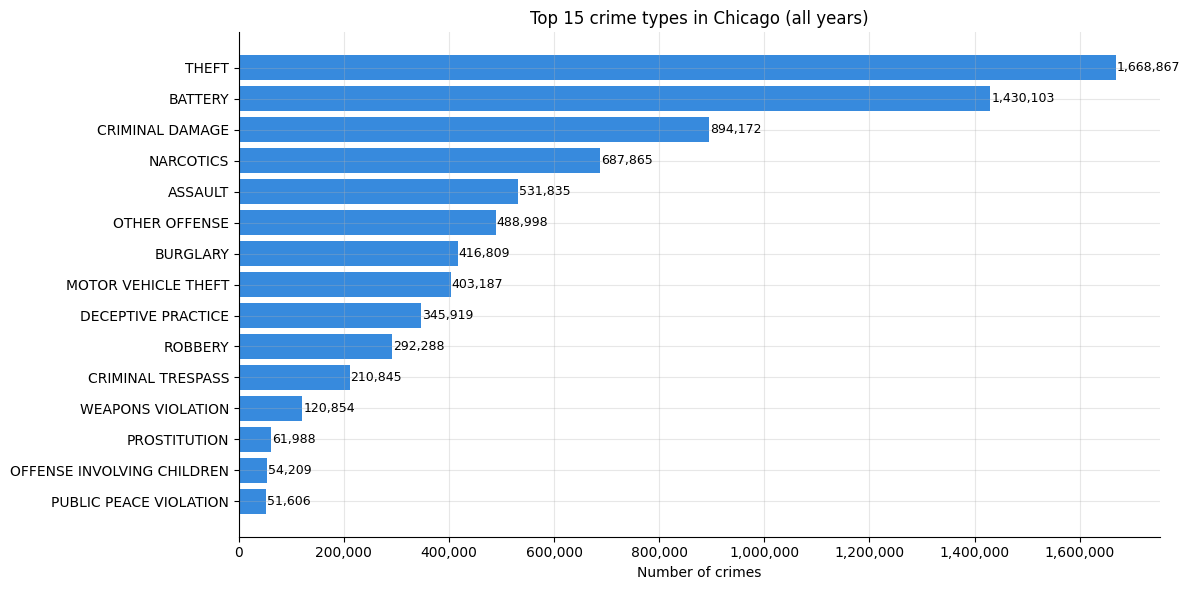

In [30]:
#Top 15 Crime Types
top_crimes = allCrimes['Primary Type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_crimes.index[::-1],
    top_crimes.values[::-1],
    color='#378ADD'
)
ax.set_xlabel('Number of crimes')
ax.set_title('Top 15 crime types in Chicago (all years)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + 2000,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot01_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()

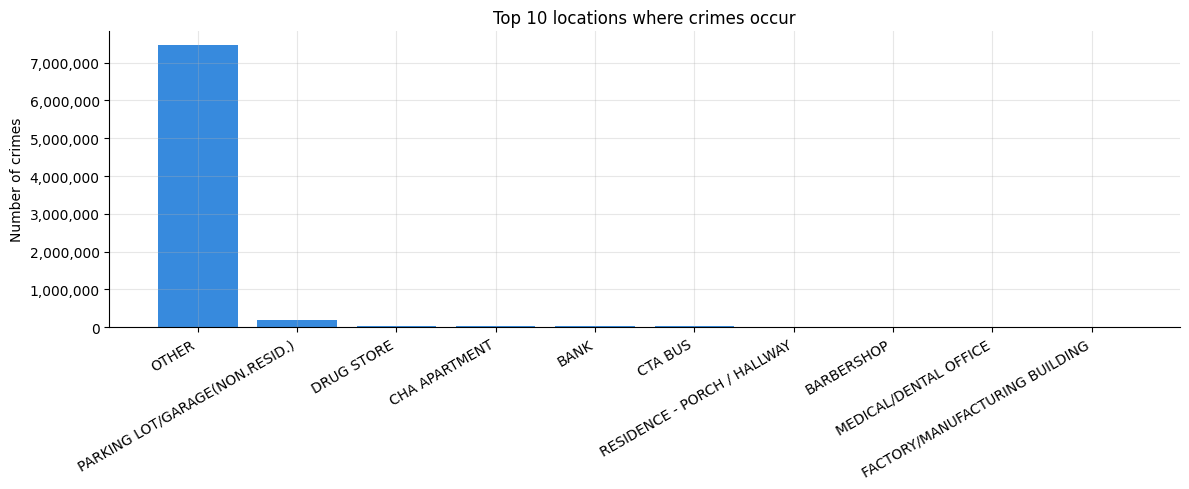

In [31]:
#Top 10 Location Types
loc_counts = allCrimes['Location Description'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(loc_counts)), loc_counts.values, color='#378ADD')
ax.set_xticks(range(len(loc_counts)))
ax.set_xticklabels(loc_counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of crimes')
ax.set_title('Top 10 locations where crimes occur')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot02_location_types.png', dpi=150, bbox_inches='tight')
plt.show()

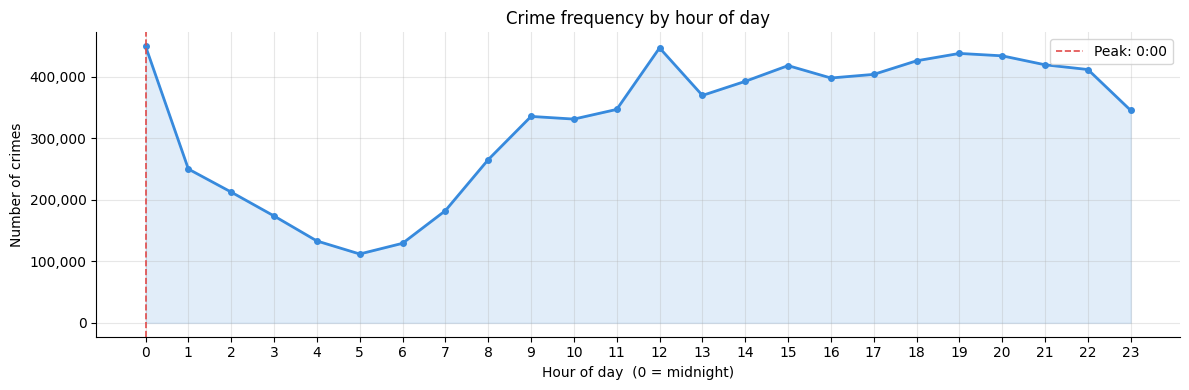

In [32]:
#Crimes by hour
hourly = allCrimes['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values,
        color='#378ADD', linewidth=2, marker='o', markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#378ADD')
ax.set_xlabel('Hour of day  (0 = midnight)')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime frequency by hour of day')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

peak_hour = int(hourly.idxmax())
ax.axvline(peak_hour, color='#E24B4A', linestyle='--', linewidth=1.2,
           label=f'Peak: {peak_hour}:00')
ax.legend()

plt.tight_layout()
plt.savefig('plot03_crimes_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

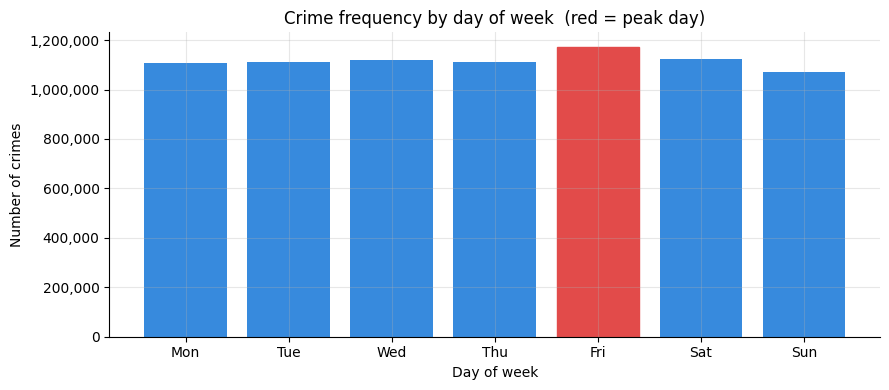

In [33]:
#Crimes by day of week
daily = allCrimes['DayOfWeek'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(DAY_NAMES, daily.values, color='#378ADD')
bars[daily.values.argmax()].set_color('#E24B4A')   # highlight peak day
ax.set_xlabel('Day of week')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime frequency by day of week  (red = peak day)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot04_crimes_by_day.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_55/3486253167.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Year', 'Primary Type'])


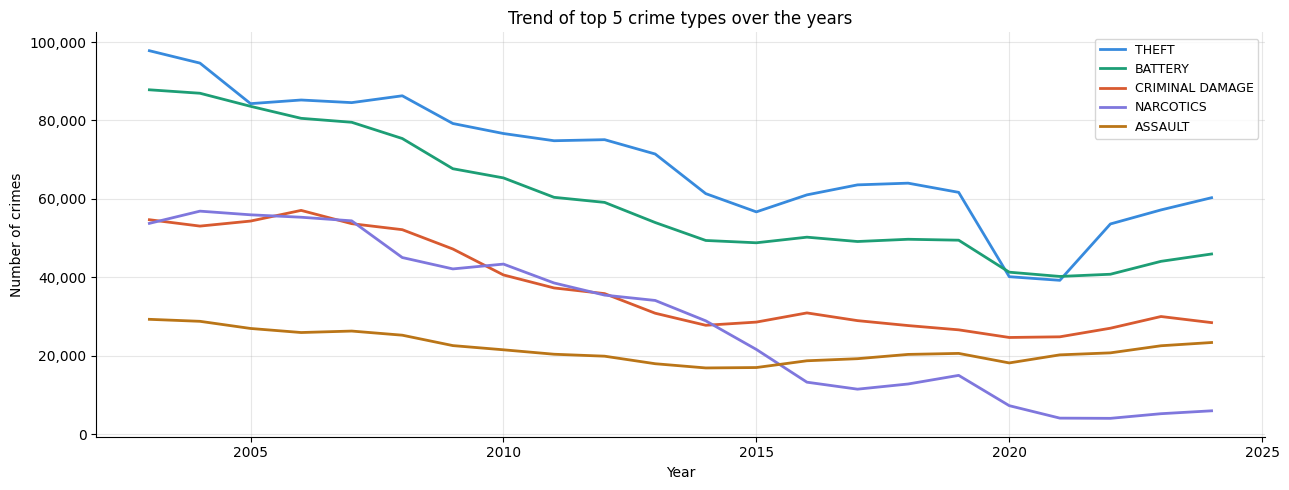

In [34]:
#Crime type trend over years (top 5)
top5 = allCrimes['Primary Type'].value_counts().head(5).index
colors_top5 = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#BA7517']

trend = (allCrimes[allCrimes['Primary Type'].isin(top5)]
         .groupby(['Year', 'Primary Type'])
         .size()
         .unstack(fill_value=0))
trend = trend[(trend.index >= 2003) & (trend.index <= 2024)]

fig, ax = plt.subplots(figsize=(13, 5))
for crime, color in zip(top5, colors_top5):
    ax.plot(trend.index, trend[crime],
            label=crime, color=color, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Number of crimes')
ax.set_title('Trend of top 5 crime types over the years')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot11_crime_type_trends.png', dpi=150, bbox_inches='tight')
plt.show()

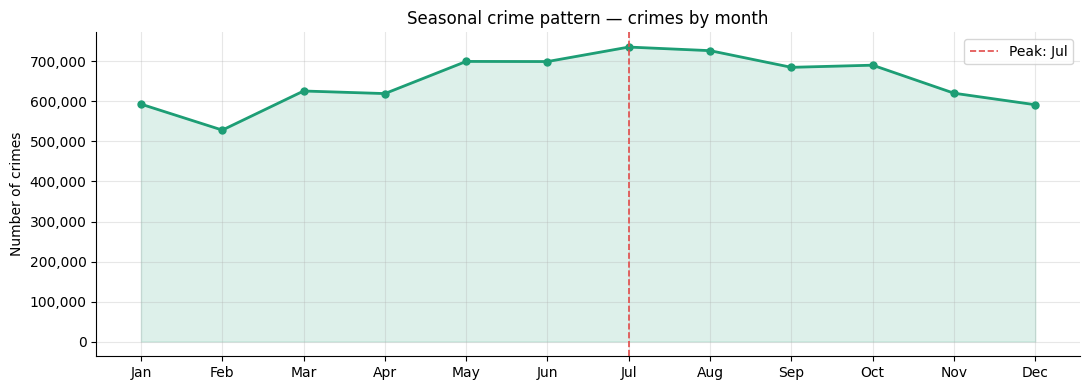

In [35]:
#Crimes by month
monthly = allCrimes['Month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, 13), monthly.values,
        color='#1D9E75', linewidth=2, marker='o', markersize=5)
ax.fill_between(range(1, 13), monthly.values, alpha=0.15, color='#1D9E75')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Number of crimes')
ax.set_title('Seasonal crime pattern — crimes by month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

peak_month = int(monthly.idxmax())
ax.axvline(peak_month, color='#E24B4A', linestyle='--', linewidth=1.2,
           label=f'Peak: {MONTH_NAMES[peak_month - 1]}')
ax.legend()

plt.tight_layout()
plt.savefig('plot05_crimes_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

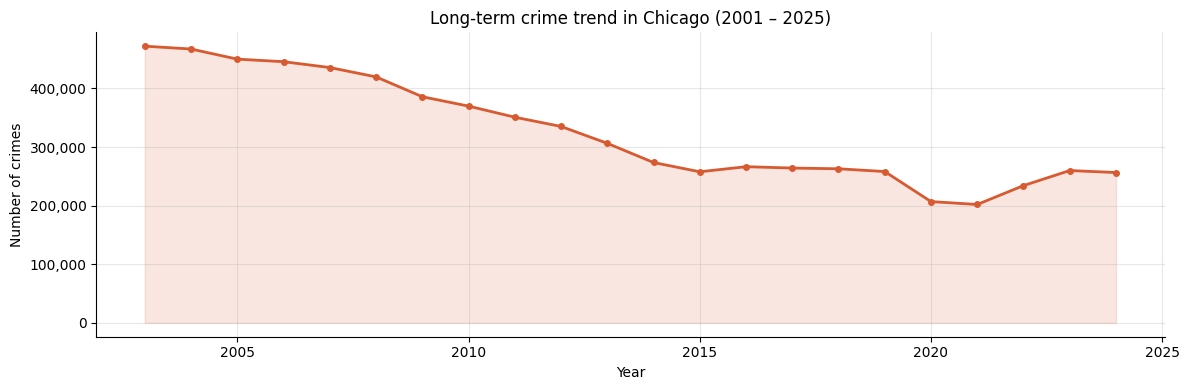

In [36]:
#Yearly Trend
yearly = allCrimes['Year'].value_counts().sort_index()
yearly = yearly[(yearly.index >= 2003) & (yearly.index <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly.index, yearly.values,
        color='#D85A30', linewidth=2, marker='o', markersize=4)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#D85A30')
ax.set_xlabel('Year')
ax.set_ylabel('Number of crimes')
ax.set_title('Long-term crime trend in Chicago (2001 – 2025)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot06_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

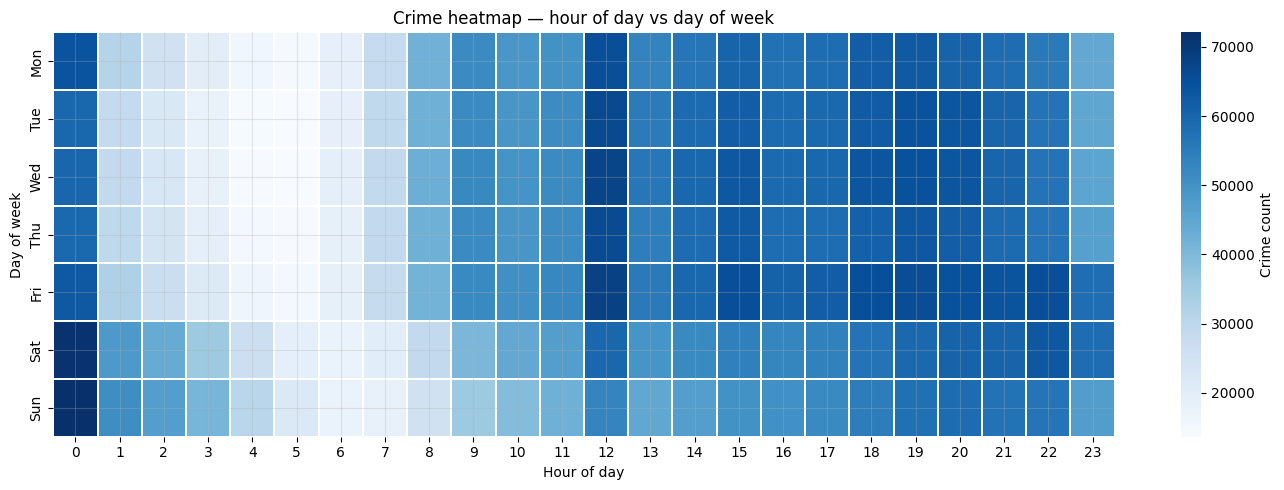

In [37]:
#Hour vs Day Heatmap
pivot_hour_day = (allCrimes
                  .groupby(['DayOfWeek', 'Hour'])
                  .size()
                  .unstack(fill_value=0))
pivot_hour_day.index = DAY_NAMES

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_hour_day,
    cmap='Blues',
    ax=ax,
    linewidths=0.2,
    fmt=',d',
    cbar_kws={'label': 'Crime count'}
)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')
ax.set_title('Crime heatmap — hour of day vs day of week')

plt.tight_layout()
plt.savefig('plot07_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_55/2780770871.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Primary Type')['Arrest']


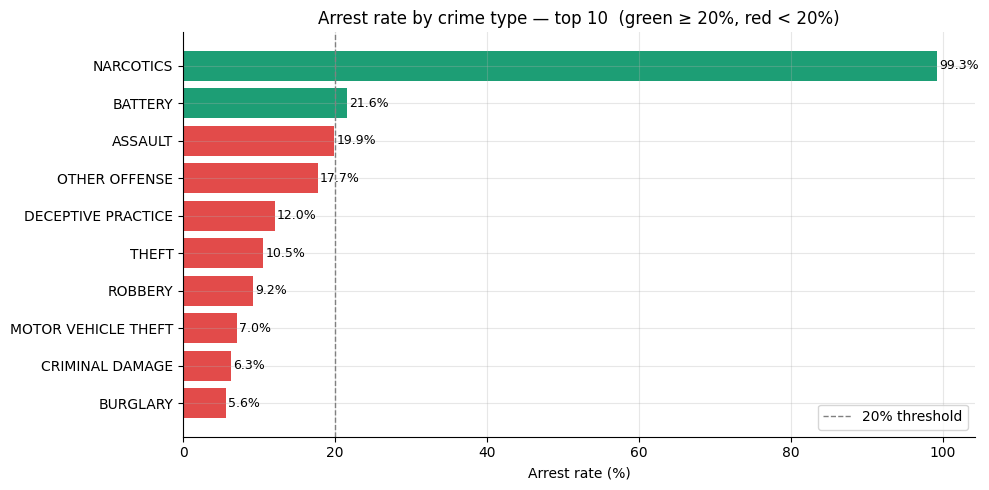

In [38]:
#Arrest rate by crime type (top 10)
top10_types = allCrimes['Primary Type'].value_counts().head(10).index

arrest_rate = (
    allCrimes[allCrimes['Primary Type'].isin(top10_types)]
    .groupby('Primary Type')['Arrest']
    .mean()
    .sort_values(ascending=True) * 100
)

colors = ['#1D9E75' if v >= 20 else '#E24B4A' for v in arrest_rate.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(arrest_rate.index, arrest_rate.values, color=colors)
ax.set_xlabel('Arrest rate (%)')
ax.set_title('Arrest rate by crime type — top 10  (green ≥ 20%, red < 20%)')
ax.axvline(20, color='gray', linestyle='--', linewidth=1, label='20% threshold')
ax.legend()

for bar, val in zip(bars, arrest_rate.values):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot08_arrest_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

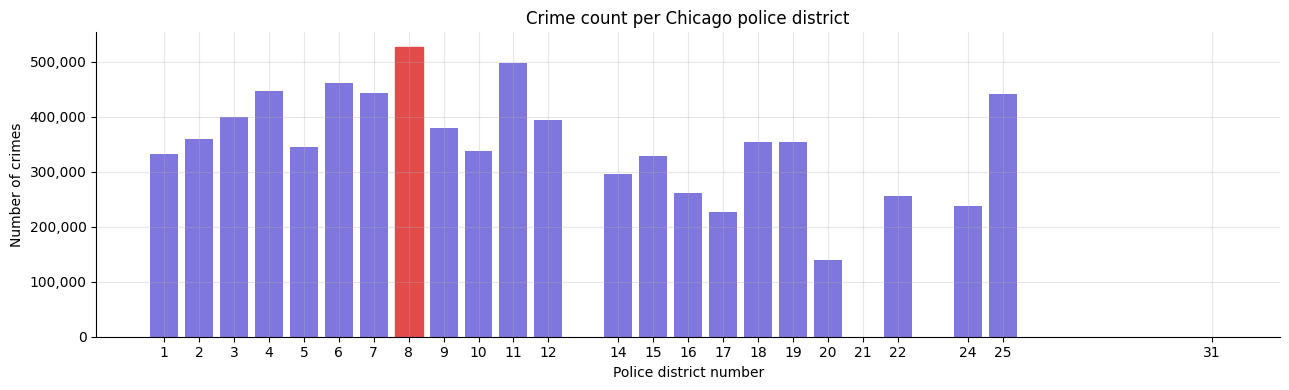

In [39]:
#Crimes per district
district_counts = (allCrimes['District']
                   .dropna()
                   .astype(int)
                   .value_counts()
                   .sort_index())

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(district_counts.index, district_counts.values, color='#7F77DD')
ax.set_xlabel('Police district number')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime count per Chicago police district')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(district_counts.index)

# highlight highest
peak_dist = district_counts.idxmax()
ax.get_children()[list(district_counts.index).index(peak_dist)].set_color('#E24B4A')

plt.tight_layout()
plt.savefig('plot09_crimes_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

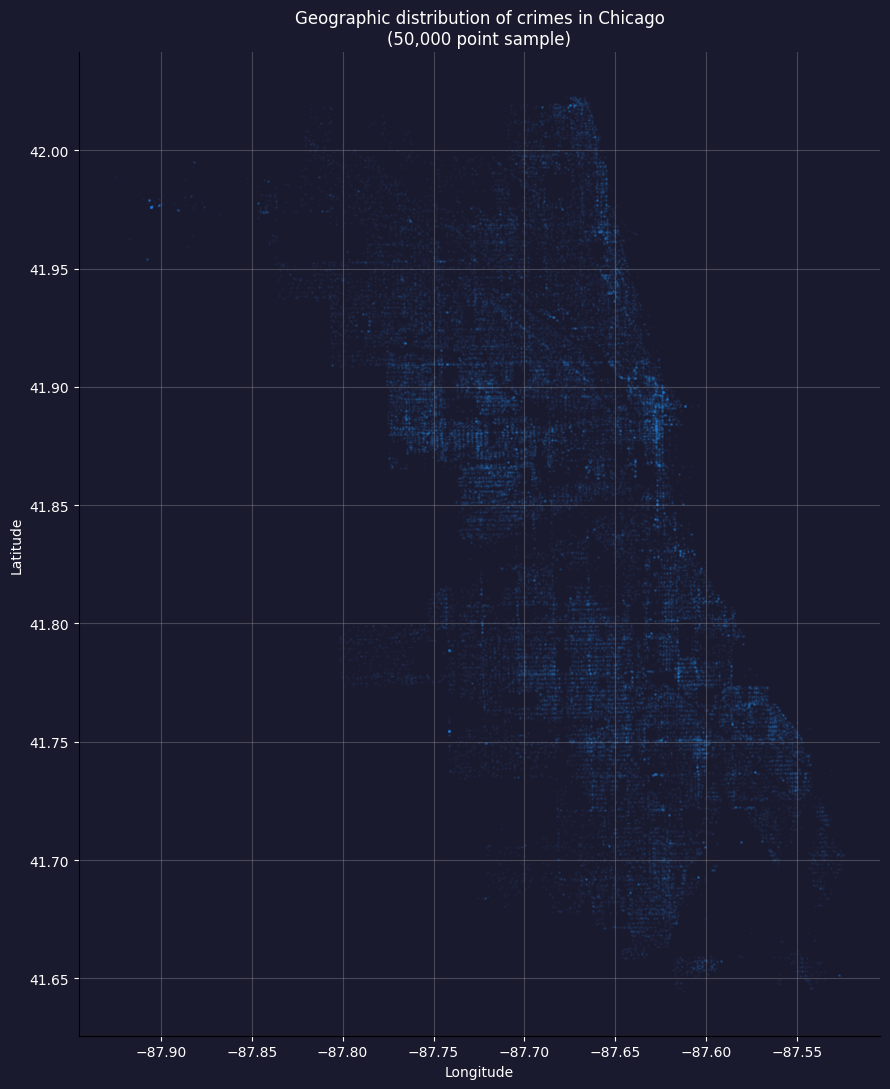

In [40]:
#Crime hotspot map
sample = allCrimes[['Latitude', 'Longitude']].dropna().sample(
    n=50000, random_state=42
)

fig, ax = plt.subplots(figsize=(9, 11))
ax.scatter(
    sample['Longitude'],
    sample['Latitude'],
    alpha=0.04,
    s=1,
    color='#378ADD'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic distribution of crimes in Chicago\n(50,000 point sample)')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

plt.tight_layout()
plt.savefig('plot10_geo_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

In [41]:
hourly   = allCrimes['Hour'].value_counts().sort_index()
monthly  = allCrimes['Month'].value_counts().sort_index()
yearly   = allCrimes['Year'].value_counts().sort_index()

In [42]:
peak_hour  = int(hourly.idxmax())
quiet_hour = int(hourly.idxmin())
peak_mon   = int(monthly.idxmax())
quiet_mon  = int(monthly.idxmin())


In [43]:
print(f"""
Time patterns:
  - Peak crime hour  : {peak_hour}:00
  - Lowest crime hour: {quiet_hour}:00
  - Peak crime month : {MONTH_NAMES[peak_mon - 1]}
  - Lowest crime month: {MONTH_NAMES[quiet_mon - 1]}
  - Peak crime day   : {DAY_NAMES[allCrimes['DayOfWeek'].value_counts().idxmax()]}

Crime type patterns:
  - Most common crime : {allCrimes['Primary Type'].value_counts().index[0]}
  - Overall arrest rate: {allCrimes['Arrest'].mean()*100:.1f}%
  - Domestic crimes   : {allCrimes['Domestic'].mean()*100:.1f}% of all crimes

Location patterns:
  - Most crime-prone district : District {int(allCrimes['District'].value_counts().index[0])}
  - Most common crime location: {allCrimes['Location Description'].value_counts().index[0]}

Long-term trend:
  - Crime in {int(yearly.index[0])}: {int(yearly.iloc[0]):,} cases
  - Crime in {int(yearly.index[-1])}: {int(yearly.iloc[-1]):,} cases
  - Overall reduction : {((yearly.iloc[0] - yearly.iloc[-1]) / yearly.iloc[0] * 100):.1f}%
""")



Time patterns:
  - Peak crime hour  : 0:00
  - Lowest crime hour: 5:00
  - Peak crime month : Jul
  - Lowest crime month: Feb
  - Peak crime day   : Fri

Crime type patterns:
  - Most common crime : THEFT
  - Overall arrest rate: 24.8%
  - Domestic crimes   : 17.4% of all crimes

Location patterns:
  - Most crime-prone district : District 8
  - Most common crime location: OTHER

Long-term trend:
  - Crime in 2001: 3,904 cases
  - Crime in 2026: 55,489 cases
  - Overall reduction : -1321.3%



In [50]:
# Recompute with complete years only
hourly  = allCrimes['Hour'].value_counts().sort_index()
monthly = allCrimes['Month'].value_counts().sort_index()
yearly  = allCrimes['Year'].value_counts().sort_index()
yearly_full = yearly[(yearly.index >= 2003) & (yearly.index <= 2024)]

In [49]:
peak_hour  = int(hourly.idxmax())
quiet_hour = int(hourly.idxmin())
peak_mon   = int(monthly.idxmax())
quiet_mon  = int(monthly.idxmin())

In [51]:
print(f"""
Time patterns:
  - Peak crime hour  : {peak_hour}:00
  - Lowest crime hour: {quiet_hour}:00
  - Peak crime month : {MONTH_NAMES[peak_mon - 1]}
  - Lowest crime month: {MONTH_NAMES[quiet_mon - 1]}
  - Peak crime day   : {DAY_NAMES[allCrimes['DayOfWeek'].value_counts().idxmax()]}

Crime type patterns:
  - Most common crime : {allCrimes['Primary Type'].value_counts().index[0]}
  - Overall arrest rate: {allCrimes['Arrest'].mean()*100:.1f}%
  - Domestic crimes   : {allCrimes['Domestic'].mean()*100:.1f}% of all crimes

Location patterns:
  - Most crime-prone district : District {int(allCrimes['District'].value_counts().index[0])}
  - Most common crime location: {allCrimes['Location Description'].value_counts().index[0]}

Long-term trend (2003–2024):
  - Crime in {int(yearly_full.index[0])}: {int(yearly_full.iloc[0]):,} cases
  - Crime in {int(yearly_full.index[-1])}: {int(yearly_full.iloc[-1]):,} cases
  - Overall reduction : {((yearly_full.iloc[0] - yearly_full.iloc[-1]) / yearly_full.iloc[0] * 100):.1f}%
""")


Time patterns:
  - Peak crime hour  : 0:00
  - Lowest crime hour: 5:00
  - Peak crime month : Jul
  - Lowest crime month: Feb
  - Peak crime day   : Fri

Crime type patterns:
  - Most common crime : THEFT
  - Overall arrest rate: 24.8%
  - Domestic crimes   : 17.4% of all crimes

Location patterns:
  - Most crime-prone district : District 8
  - Most common crime location: OTHER

Long-term trend (2003–2024):
  - Crime in 2003: 471,995 cases
  - Crime in 2024: 256,471 cases
  - Overall reduction : 45.7%



## CLUSTERING

In [60]:
from pyspark.sql.functions import col, hour, to_timestamp, dayofweek

# 1. Convert 'Date' string to Spark Timestamp
# This handles the "10/05/2023 11:30:00 PM" format
df_spark = df_spark.withColumn("Timestamp", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))

# 2. Extract Hour and DayOfWeek (This fixes your 'Unresolved Column' error)
df_spark = df_spark.withColumn("Hour", hour(col("Timestamp")))
df_spark = df_spark.withColumn("DayOfWeek", dayofweek(col("Timestamp")))

# 3. Clean: Keep only what we need and drop nulls
# We include 'Arrest' because it's our target for the Random Forest later
df_clean = df_spark.select("Latitude", "Longitude", "Hour", "DayOfWeek", "District", "Arrest").dropna()

print(f"Data ready. Total rows for processing: {df_clean.count()}")

Data ready. Total rows for processing: 8436223


In [61]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# 1. Create a 3D feature set for clustering
assembler = VectorAssembler(inputCols=["Latitude", "Longitude", "Hour"], outputCol="raw_features")
v_data = assembler.transform(df_clean)

# 2. Scale the features
scaler = StandardScaler(inputCol="raw_features", outputCol="scaledFeatures", withStd=True, withMean=False)
scaler_model = scaler.fit(v_data)
final_data = scaler_model.transform(v_data)

In [62]:
from pyspark.ml.clustering import BisectingKMeans

# Train the model on the full 7.8M rows
bkm = BisectingKMeans().setK(30).setSeed(42).setFeaturesCol("scaledFeatures")
cluster_model = bkm.fit(final_data)

# Assign Cluster IDs (This creates the 'prediction' column)
clustered_data = cluster_model.transform(final_data)

print("Clustering complete. The 'Big Blob' has been broken into 30 distinct zones.")

Clustering complete. The 'Big Blob' has been broken into 30 distinct zones.


In [63]:
# Count how many crimes fell into each cluster
cluster_counts = clustered_data.groupBy("prediction").count().orderBy("count", ascending=False)

print("--- Crime Distribution Across Clusters ---")
cluster_counts.show(n=30)

# Logic: If the 'count' for Cluster 0 is 10x larger than others, 
# you might need to increase K (number of clusters).

--- Crime Distribution Across Clusters ---


+----------+------+
|prediction| count|
+----------+------+
|         8|507712|
|        10|451103|
|        14|429628|
|        20|380598|
|        28|371209|
|        15|347302|
|        18|342379|
|        13|323182|
|        25|311738|
|         5|301371|
|        17|298727|
|        21|297371|
|         6|292942|
|        29|291693|
|        23|291361|
|        19|287079|
|        11|278105|
|         0|274967|
|        26|253447|
|        22|241138|
|         3|239347|
|         4|226570|
|         7|213367|
|        12|213196|
|        16|197592|
|         1|193330|
|         2|190979|
|        24|190097|
|        27|149439|
|         9| 49254|
+----------+------+



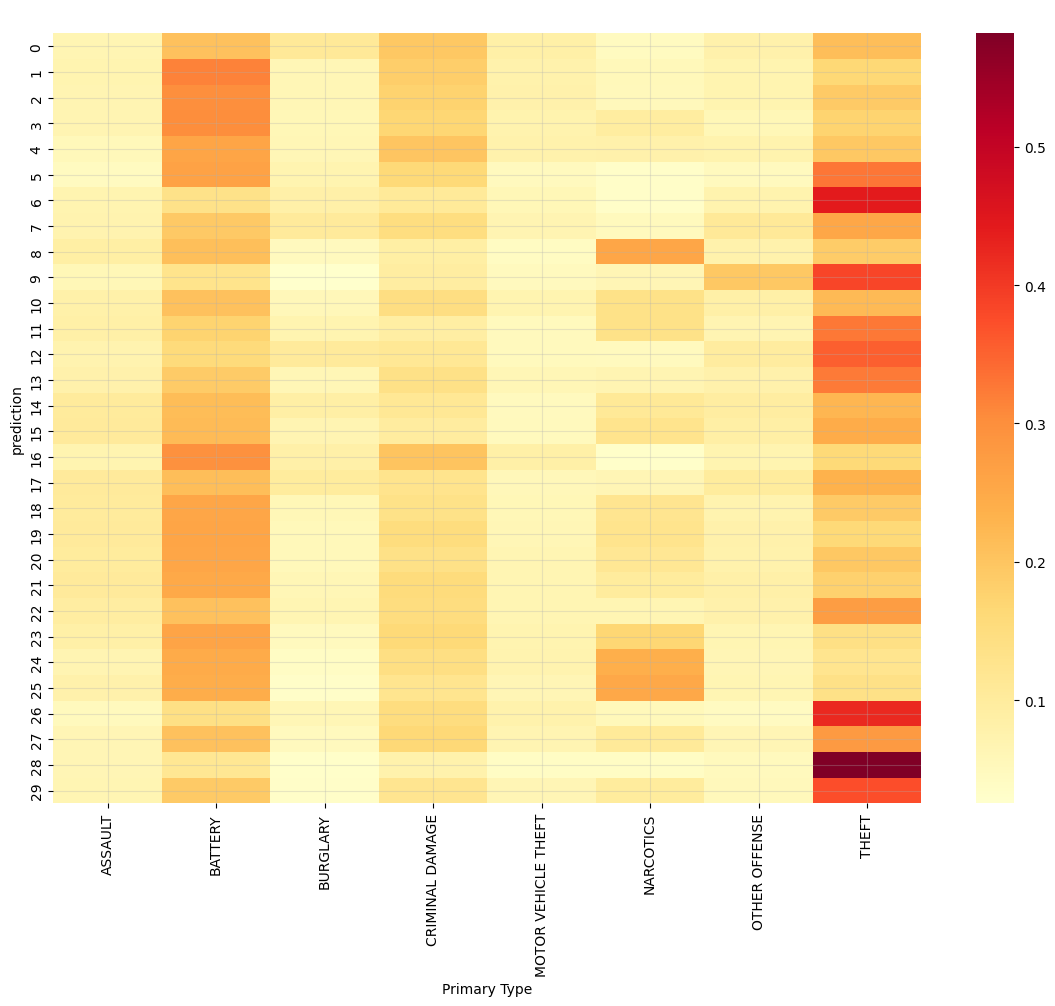

In [82]:
from pyspark.sql.functions import desc, col

# Get the labels for the heatmap
top_crimes_list = clustered_data.groupBy("Primary Type").count().orderBy(desc("count")).limit(8).toPandas()['Primary Type'].tolist()

# Prepare the pivot
pivot_data = clustered_data.filter(col("Primary Type").isin(top_crimes_list)).groupBy("prediction", "Primary Type").count().toPandas()
pivot_df = pivot_data.pivot(index="prediction", columns="Primary Type", values="count").fillna(0)
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Cyberpunk-style Heatmap to match your other plots
plt.figure(figsize=(14, 10))
plt.title('Criminal Identity per Hotspot', color='white', size=16)
sns.heatmap(pivot_norm, cmap="YlOrRd", annot=False)
plt.show()

/tmp/ipykernel_55/1789428361.py:4: FutureWarning:                               

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_counts_pd, x='prediction', y='count', palette='magma')


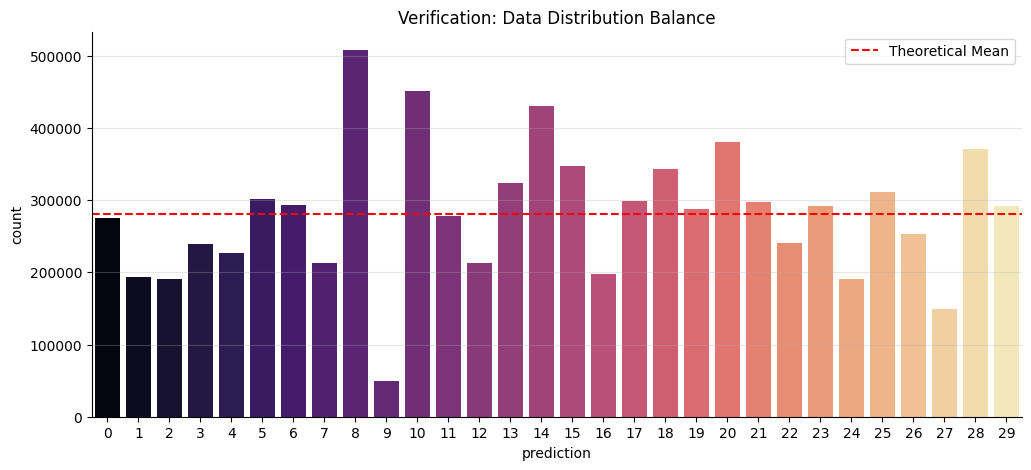

/tmp/ipykernel_55/1789428361.py:14: FutureWarning:                              

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_pd, x='prediction', y='Hour', palette='Spectral')


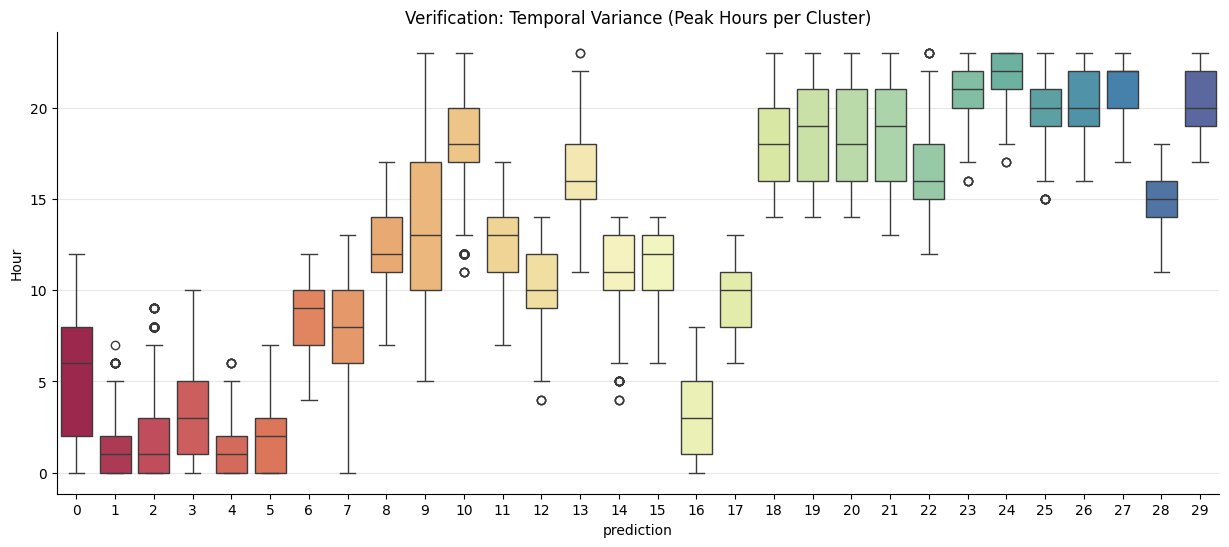

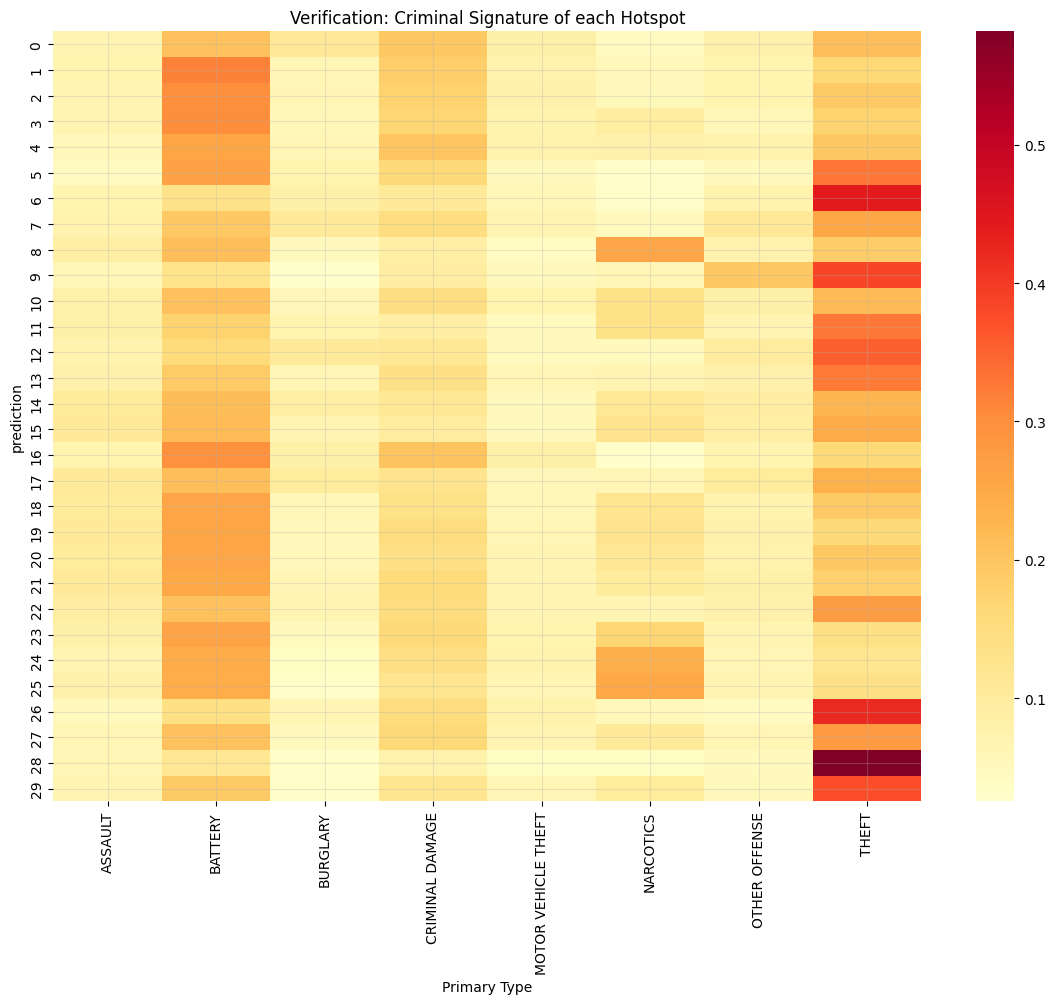

In [83]:
# 1. BALANCE CHECK: Distribution of 7.8M rows across 30 Clusters
cluster_counts_pd = clustered_data.groupBy("prediction").count().orderBy("prediction").toPandas()
plt.figure(figsize=(12, 5))
sns.barplot(data=cluster_counts_pd, x='prediction', y='count', palette='magma')
plt.axhline(y=clustered_data.count()/30, color='red', linestyle='--', label='Theoretical Mean')
plt.title('Verification: Data Distribution Balance')
plt.legend()
plt.show()

# 2. TEMPORAL CHECK: Do clusters represent different times of day?
# We sample 100k rows to keep the boxplot fast
sample_pd = clustered_data.select("prediction", "Hour").sample(False, 0.01).toPandas()
plt.figure(figsize=(15, 6))
sns.boxplot(data=sample_pd, x='prediction', y='Hour', palette='Spectral')
plt.title('Verification: Temporal Variance (Peak Hours per Cluster)')
plt.show()

# 3. SIGNATURE CHECK: Crime Type Heatmap
top_crimes = clustered_data.groupBy("Primary Type").count().orderBy(desc("count")).limit(8).toPandas()['Primary Type'].tolist()
pivot_data = clustered_data.filter(col("Primary Type").isin(top_crimes)).groupBy("prediction", "Primary Type").count().toPandas()
pivot_df = pivot_data.pivot(index="prediction", columns="Primary Type", values="count").fillna(0)
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0)
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_norm, cmap="YlOrRd", annot=False)
plt.title('Verification: Criminal Signature of each Hotspot')
plt.show()

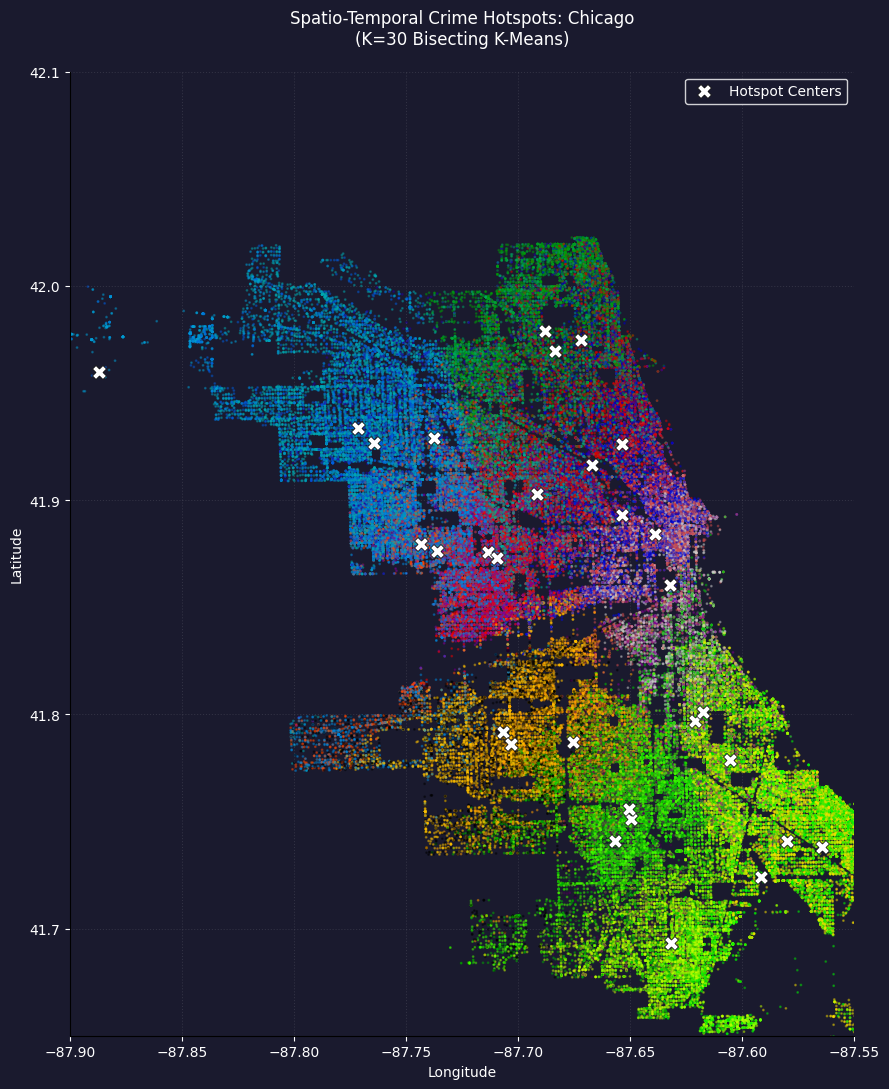

In [77]:
# 1. Setup the figure with your dark theme styling
fig, ax = plt.subplots(figsize=(9, 11))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# 2. Plot the clustered points
# We use 'tab20b' + 'tab20c' or 'nipy_spectral' for highly distinct cluster colors
scatter = ax.scatter(
    map_sample['Longitude'], 
    map_sample['Latitude'], 
    c=map_sample['prediction'], 
    cmap='nipy_spectral', 
    alpha=0.4, 
    s=1
)

# 3. Plot the Centroids (The "Hotspot Hearts")
# White edgecolors make them glow against the dark background
ax.scatter(
    centers_pd['avg(Longitude)'], 
    centers_pd['avg(Latitude)'], 
    marker='X', 
    s=100, 
    color='white', 
    edgecolors='black', 
    linewidth=0.5,
    label='Hotspot Centers'
)

# 4. Strict Coordinate and Label Styling
ax.set_ylim(41.65, 42.1)   # Slightly tighter on the North for better fit
ax.set_xlim(-87.90, -87.55)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title('Spatio-Temporal Crime Hotspots: Chicago\n(K=30 Bisecting K-Means)', color='white', pad=20)

# Make ticks and grid visible but subtle
ax.tick_params(colors='white')
ax.grid(color='white', linestyle=':', alpha=0.1)

# Add a subtle legend
legend = ax.legend(facecolor='#1a1a2e', edgecolor='white')
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.savefig('final_hotspot_map.png', dpi=150, facecolor='#1a1a2e')
plt.show()